In [11]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2 as cv

In [19]:
# Directories containing the "liked sound," which serves as the template, and the clips to be processed

liked_folder = "/home/super/data/music/Liked Sounds/Location A Sand Forrest/Ultrasonic"
clips = "/home/super/data/music/Location A (Sand Forrest)/LA_Sand_Forrest_ULTRASONIC_03-05-25"

In [13]:
# Processes a specific audio file from the "Liked Sounds" folder

for file in os.listdir(liked_folder):
    if file.lower().endswith(".wav"):
        audio_path = os.path.join(liked_folder, file)
        break

print(f"Processing: {audio_path}")

Processing: /home/super/data/music/Liked Sounds/Location A Sand Forrest/Ultrasonic/SERRA_20250503_200235.wav


In [14]:
# Loads the audio file and finds the sample rate using the librosa library

y, sr = librosa.load(audio_path, sr=None)
print(f"Original sample rate: {sr} Hz")

Original sample rate: 256000 Hz


In [15]:
# Generates STFT spectrogram of the liked audio file and converts it to a decibel scale

n_fft = 2048
hop_length = 512
D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

In [16]:
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
energy_per_freq = S_db.max(axis=1)
valid_bins = np.where(energy_per_freq > -80)[0]
fmin = freqs[valid_bins[0]]
fmax = freqs[valid_bins[-1]]

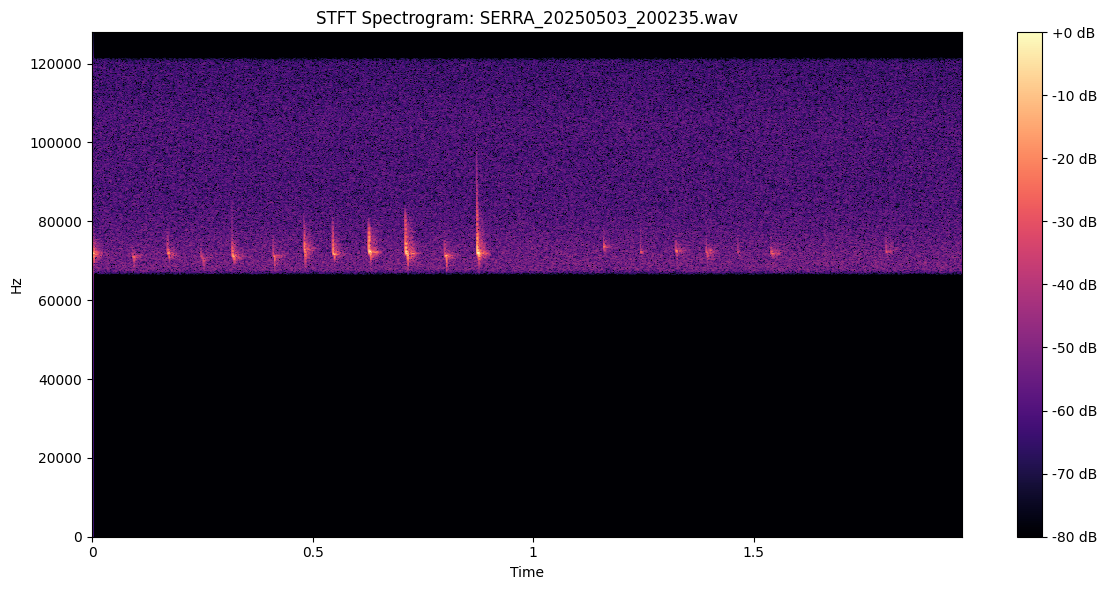

In [17]:
# Visualizes STFT spectrogram for the liked audio file (used as template)

plt.figure(figsize=(12, 6))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='linear')
plt.colorbar(format="%+2.0f dB")
plt.title(f"STFT Spectrogram: {file}")
plt.ylim([fmin, fmax])
plt.tight_layout()
plt.show()

In [22]:
def spectrogram_to_image(S_dB):
    img = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min())
    img = (img * 255).astype(np.uint8)
    return img

In [28]:
audio_paths = []

for file in os.listdir(clips):
    if file.lower().endswith(".wav"):
        audio_path = os.path.join(clips, file)
        audio_paths.append(audio_path)

template_img = spectrogram_to_image(S_db)

In [ ]:
THRESHOLD = 0.6

for audio_path in audio_paths:
    print(f"Processing: {audio_path}")
    
    y_clip, sr_clip = librosa.load(audio_path, sr=None)
    
    if sr_clip != sr:
        print(f"Resampling {audio_path} from {sr_clip} Hz to {sr} Hz")
        y_clip = librosa.resample(y_clip, orig_sr=sr_clip, target_sr=sr)

    D_clip = librosa.stft(y_clip, n_fft=n_fft, hop_length=hop_length)
    S_db_clip = librosa.amplitude_to_db(np.abs(D_clip), ref=np.max)

    clip_img = spectrogram_to_image(S_db_clip)

    res = cv.matchTemplate(clip_img, template_img, cv.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    if max_val >= THRESHOLD:
        print(f"Match found in {audio_path} with score: {max_val:.4f}")
        top_left = max_loc
        h, w = template_img.shape[:2]
        bottom_right = (top_left[0] + w, top_left[1] + h)

        cv.rectangle(clip_img, top_left, bottom_right, 255, 2)
        plt.figure(figsize=(10, 5))
        plt.imshow(clip_img, cmap='gray')
        plt.title(f"Match in {audio_path} at {top_left}")
        plt.axis('off')
        plt.show()
    else:
        print(f"No significant match found in {audio_path}")

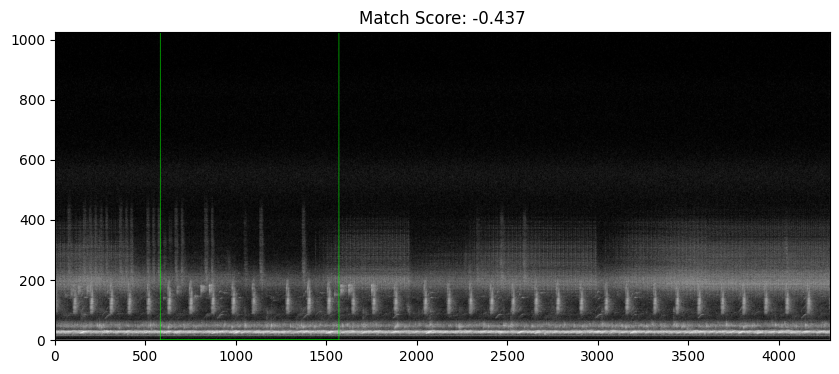

In [24]:
top_left = max_loc
h, w = template_img.shape
bottom_right = (top_left[0] + w, top_left[1] + h)

vis = cv.cvtColor(clip_img, cv.COLOR_GRAY2BGR)
cv.rectangle(vis, top_left, bottom_right, (0, 255, 0), 2)

plt.figure(figsize=(10, 4))
plt.imshow(vis, aspect='auto', origin='lower', cmap='gray')
plt.title(f"Match Score: {max_val:.3f}")
plt.show()